First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)

Accuracy Score:
1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       

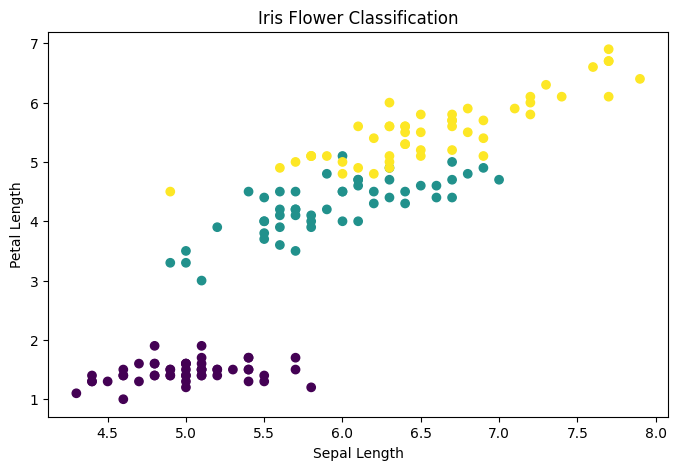

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

#load iris dataset
iris=load_iris()

#create dataframe
df=pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df['species']=iris.target
print("First 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

#features and target
x=iris.data
y=iris.target

#split dataset
X_train,X_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("\nTraining Data Shape:",X_train.shape)
print("Testing Data Shape:",X_test.shape)

#train model
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

#prediction
y_pred=model.predict(X_test)

#Accuracy
accuracy=accuracy_score(y_test,y_pred)
print("\nAccuracy Score:")
print(accuracy)

#confusion matrix
cm=confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix:")
print(cm)

#classification report
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

#sample prediction
sample_flower=[[5.1,3.5,1.4,0.2]]
prediction=model.predict(sample_flower)
species_name=iris.target_names

print("\nPredicted Flower Species:")
print(species_name[prediction[0]])

#visulaization
plt.figure(figsize=(8,5))
plt.scatter(
    df['sepal length (cm)'],
    df['petal length (cm)'],
    c=df['species']
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Iris Flower Classification")
plt.show()